# PCA Multifactor Statistical Arbitrage

**A third, more advanced strategy** — extending the single-index market-neutral idea to hedge against MANY systematic factors at once, using Principal Component Analysis.

## What's new versus the single-index version

The earlier stat-arb strategy hedged the stock against one index (QQQ). That removes the broad market but leaves the stock exposed to other systematic forces — high-beta risk, size, value, momentum. This version hedges against a diversified basket of factor ETFs, using **PCA** to extract the handful of independent underlying factors that drive them, then neutralizing all of them at once. What's left is a cleaner, more genuinely stock-specific residual.

## Two deliberate design choices

**Stock: Costco (COST), not Tesla.** TSLA is dominated by options-market mechanics that make its idiosyncratic moves unusual and hard to generalize — a poor choice for isolating a normal residual. COST trended up steadily, is driven by ordinary fundamentals, and is a moderate index weight (avoiding the 'hedging a stock against itself' problem that afflicts mega-caps like AAPL).

**Hedge basket: diversified factor ETFs, no single-sector ETFs.** SPY, QQQ, IWM, SPHB, SPLV, MTUM, VLUE span the market plus the main style/risk factors. Sector ETFs are deliberately excluded — COST is a large weight in the consumer-staples ETF, so hedging against it would reintroduce the self-hedging problem.

## Honesty note

A cleaner stock and a proper multifactor hedge improve the *methodology* and isolate a cleaner residual, but may still not yield a profitable signal — efficient markets are efficient. Parameters are fixed a priori; both signal directions are tested; the out-of-sample period is examined once. We accept whatever the data says.

In [1]:
import sys, os
for _c in ("../src", "src"):
    if os.path.isdir(_c):
        sys.path.insert(0, _c); break
else:
    raise RuntimeError("Could not locate src/ from: " + os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_utils import fetch_close_prices, fetch_price_data
from pca_hedge import compute_returns, estimate_rolling_hedge, compute_signal
from mf_backtest import run_mf_backtest
import metrics as m

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Pull the stock and the hedge-ETF basket

All aligned on a common calendar. We also pull the stock's daily opens for realistic next-day-open execution.

In [2]:
STOCK = "COST"
ETFS  = ["SPY", "QQQ", "IWM", "SPHB", "SPLV", "MTUM", "VLUE"]
START, END = "2015-01-01", "2025-08-31"

closes = fetch_close_prices([STOCK] + ETFS, START, END)
stock_bars = fetch_price_data(STOCK, START, END)

stock_close = closes[STOCK]
stock_open  = stock_bars["open"].reindex(closes.index)
etf_closes  = closes[ETFS]

# Sanity-check the stock actually trended up over the sample
tot = stock_close.iloc[-1] / stock_close.iloc[0] - 1
print(f"{STOCK}: {closes.index[0].date()} to {closes.index[-1].date()}, total price change {tot:.0%}")
closes.tail()

COST: 2015-01-02 to 2025-08-29, total price change 725%


,COST,IWM,MTUM,QQQ,SPHB,SPLV,SPY,VLUE
date,,,,,,,,
2025-08-25,937.6065,229.9714,241.1266,567.5864,103.6882,72.2316,635.4292,116.6740
2025-08-26,937.3676,231.8717,243.4402,569.8654,104.3538,72.1334,638.0898,116.8800
2025-08-27,945.5131,233.5146,243.0430,570.7412,104.8405,72.3690,639.5436,117.5176
2025-08-28,940.9722,233.7917,244.5820,574.3140,105.6849,71.8487,641.8086,117.7923
2025-08-29,939.3392,232.7525,242.0103,567.6661,104.1749,72.1531,637.9810,117.3999


## 2. Build the rolling PCA hedge and the residual

For each day, using only trailing data: run PCA on the ETF basket to extract the main factors, hedge the stock against them, and record the leftover residual (idiosyncratic) return. `n_components` shows how many factors the PCA kept each day.

In [3]:
stock_rets = stock_close.pct_change().dropna()
etf_rets   = compute_returns(etf_closes).reindex(stock_rets.index).dropna()
stock_rets = stock_rets.reindex(etf_rets.index)

weights, residual, ncomp = estimate_rolling_hedge(
    etf_rets, stock_rets, window=60, var_threshold=0.95, max_components=5, min_components=3
)
print(f"Principal components used: {ncomp.dropna().mean():.1f} on average "
      f"(range {int(ncomp.min())}-{int(ncomp.max())})")

# Show the average hedge weight on each ETF (how the replicating basket looks)
print("\nAverage hedge weight per ETF:")
print(weights.mean().round(3).to_string())

Principal components used: 3.2 on average (range 3-4)

Average hedge weight per ETF:
SPY     0.2030
QQQ     0.1820
IWM    -0.0740
SPHB   -0.1110
SPLV    0.3770
MTUM    0.2170
VLUE    0.0700


## 3. Test both signal directions (gross, before costs)

Same honest procedure as before: check whether the residual signal has any predictive value, and in which direction, using the in-sample data. Set `DIRECTION` in Section 4 to whichever wins here.

In [4]:
def gross_sharpe(signal, resid):
    g = (signal.shift(1) * resid).dropna()
    return (g.mean()/g.std()*np.sqrt(252), (1+g).prod()-1) if g.std() > 0 else (np.nan, np.nan)

for direction in ["momentum", "reversal"]:
    s = compute_signal(residual, lookback=21, skip=1, entry_z=0.5, direction=direction)["signal"]
    sh, cr = gross_sharpe(s, residual)
    n_ch = (s != s.shift(1)).sum()
    print(f"{direction:9s} | gross Sharpe {sh:6.3f} | gross cum.return {cr:7.3f} | signal changes {n_ch}")

momentum  | gross Sharpe  0.045 | gross cum.return  -0.033 | signal changes 353
reversal  | gross Sharpe -0.045 | gross cum.return  -0.150 | signal changes 353


## 4. Run the full multifactor backtest (net of costs)

Long the stock, short the PCA-replicating ETF basket (or the reverse). Trading costs on every leg, borrow fees on short notional, no leverage. **Set `DIRECTION` from Section 3.**

In [5]:
DIRECTION = "momentum"   # <-- set from Section 3

sig = compute_signal(residual, lookback=21, skip=1, entry_z=0.5, direction=DIRECTION)["signal"]

equity_curve, trades = run_mf_backtest(
    stock_close.reindex(stock_rets.index), stock_open.reindex(stock_rets.index),
    etf_rets, weights, sig, stock_rets,
    initial_capital=100_000.0, cost_bps_per_side=7.0, borrow_rate=0.01,
)
print(f"Trades: {len(trades)}")
print(f"Final equity: ${equity_curve['equity'].iloc[-1]:,.0f}")
print(f"Days in a position: {(equity_curve['direction'] != 0).mean():.1%}")
equity_curve.tail()

Trades: 179
Final equity: $85,234
Days in a position: 57.4%


,equity,direction,daily_pnl
date,,,
2025-08-25,"85,388.1476",1,-334.9354
2025-08-26,"85,294.9983",1,-93.1492
2025-08-27,"85,234.4836",0,-60.5148
2025-08-28,"85,234.4836",0,0.0000
2025-08-29,"85,234.4836",0,0.0000


## 5. Neutrality — now across MANY factors

The single-index version proved neutrality to one index. This proves it against the whole factor basket at once. We want: near-zero beta to the market, AND a small maximum exposure to ANY factor, AND a low multifactor R² (no combination of factors explains our returns).

In [6]:
strat_ret = equity_curve["equity"].pct_change().dropna()
spy_ret   = etf_rets["SPY"].reindex(strat_ret.index)

neut = m.market_neutrality(strat_ret, spy_ret)
mf   = m.multifactor_neutrality(strat_ret, etf_rets.reindex(strat_ret.index))
port = m.portfolio_metrics(equity_curve, "equity")

print("=== NEUTRALITY (the headline) ===")
print(f"  Beta to market (SPY):        {neut['beta_to_market']:.4f}   (target ~0)")
print(f"  Correlation to market:       {neut['correlation_to_market']:.4f}   (target ~0)")
print(f"  Max exposure to ANY factor:  {mf['max_abs_factor_beta']:.4f}   (target small)")
print(f"  Multifactor R^2 (all 7):     {mf['r_squared']:.4f}   (target low)")
print(f"  Annualized alpha:            {mf['annualized_alpha']:.4f}")
print()
print("=== PERFORMANCE ===")
for k in ["sharpe_ratio","sortino_ratio","annualized_volatility","max_drawdown","total_return","cagr"]:
    print(f"  {k:22s} {port[k]:.4f}")

=== NEUTRALITY (the headline) ===
  Beta to market (SPY):        -0.0608   (target ~0)
  Correlation to market:       -0.1890   (target ~0)
  Max exposure to ANY factor:  0.0708   (target small)
  Multifactor R^2 (all 7):     0.0561   (target low)
  Annualized alpha:            -0.0074

=== PERFORMANCE ===
  sharpe_ratio           -0.2312
  sortino_ratio          -0.2384
  annualized_volatility  0.0578
  max_drawdown           -0.1685
  total_return           -0.1477
  cagr                   -0.0149


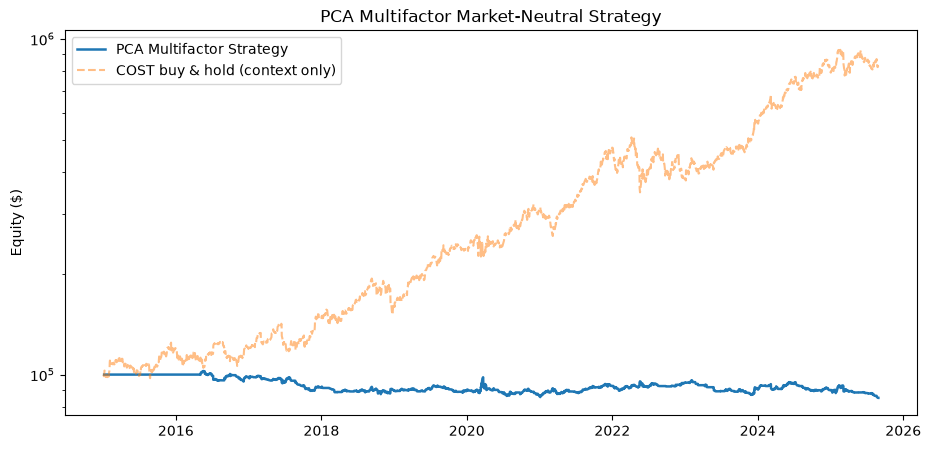

In [7]:
tsla_bh = 100_000 * stock_close / stock_close.iloc[0]
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(equity_curve.index, equity_curve["equity"], label="PCA Multifactor Strategy", linewidth=1.8)
ax.plot(tsla_bh.index, tsla_bh, label=f"{STOCK} buy & hold (context only)", linestyle="--", alpha=0.5)
ax.set_title("PCA Multifactor Market-Neutral Strategy"); ax.set_ylabel("Equity ($)")
ax.legend(); ax.set_yscale("log"); plt.show()

## 6. In-sample / out-of-sample validation

Split at 2022-01-01. Re-estimate the PCA hedge and rerun on each half independently with the same parameters. Check that neutrality holds AND whether the alpha survives out-of-sample.

In [8]:
SPLIT = "2022-01-01"
results = {}
for label, mask in [("In-Sample", stock_rets.index < SPLIT), ("Out-of-Sample", stock_rets.index >= SPLIT)]:
    sr = stock_rets[mask]; er = etf_rets.reindex(sr.index)
    w, res, _ = estimate_rolling_hedge(er, sr, window=60, var_threshold=0.95, max_components=5, min_components=3)
    s = compute_signal(res, lookback=21, skip=1, entry_z=0.5, direction=DIRECTION)["signal"]
    eq, trs = run_mf_backtest(stock_close.reindex(sr.index), stock_open.reindex(sr.index),
                              er, w, s, sr, cost_bps_per_side=7.0, borrow_rate=0.01)
    stret = eq["equity"].pct_change().dropna()
    nt = m.market_neutrality(stret, er["SPY"].reindex(stret.index))
    mff = m.multifactor_neutrality(stret, er.reindex(stret.index))
    pm = m.portfolio_metrics(eq, "equity")
    results[label] = {"sharpe": pm["sharpe_ratio"], "total_return": pm["total_return"],
                      "max_drawdown": pm["max_drawdown"], "beta_to_market": nt["beta_to_market"],
                      "max_abs_factor_beta": mff["max_abs_factor_beta"],
                      "annualized_alpha": mff["annualized_alpha"], "num_trades": len(trs)}
pd.DataFrame(results)

,In-Sample,Out-of-Sample
sharpe,-0.1680,-0.3776
total_return,-0.0748,-0.0708
max_drawdown,-0.1639,-0.1024
beta_to_market,-0.0865,0.0000
max_abs_factor_beta,0.0965,0.0871
annualized_alpha,-0.0004,-0.0204
num_trades,109.0000,47.0000
